Accuracy: 0.9000


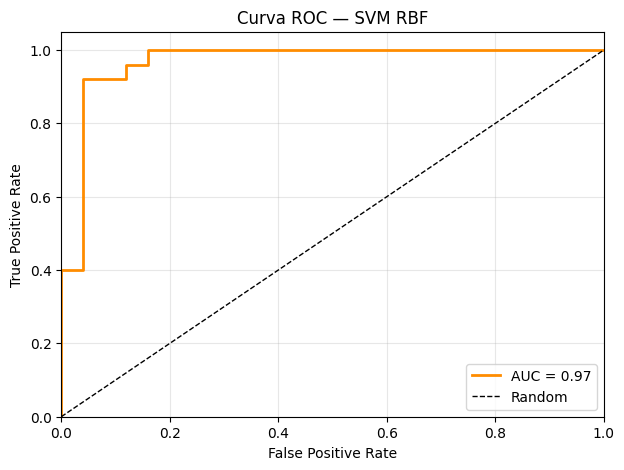

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

iris = datasets.load_iris()
X = iris.data          # ← 4 features
y = iris.target
X = X[y != 0]
y = y[y != 0]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

clf = svm.SVC(kernel='rbf', C=20.0, gamma='scale', probability=True)  # ← gamma corregido
clf.fit(X_train, y_train)

print(f"Accuracy: {clf.score(X_test, y_test):.4f}")

# Curva ROC
y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=2)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — SVM RBF')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()



> Con 3 clases y matriz de confusion




Accuracy: 0.9600


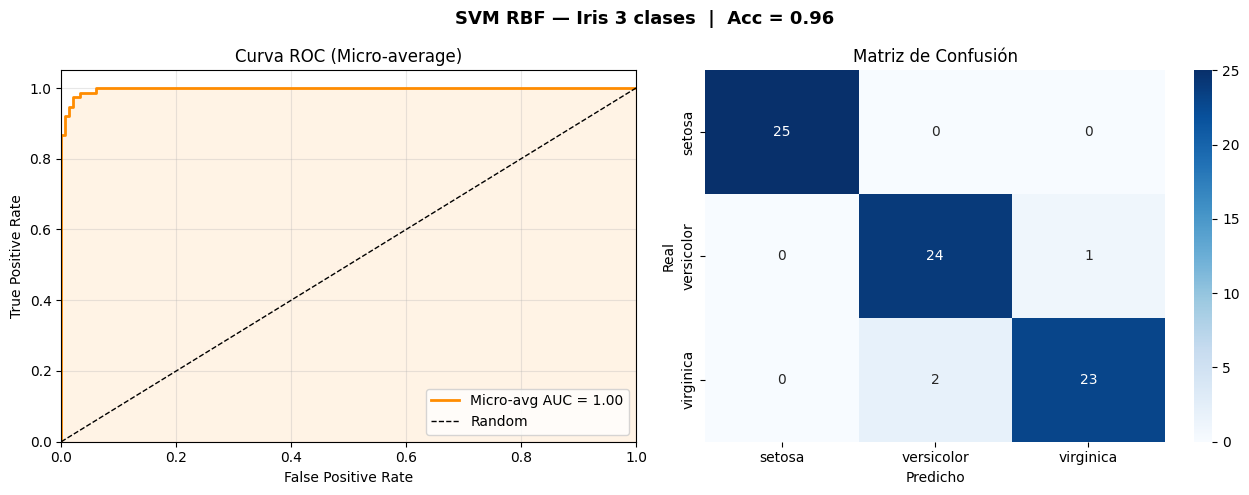

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns

# ── Datos ─────────────────────────────────────────────────────────────────────
iris = datasets.load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

y_bin = label_binarize(y, classes=[0, 1, 2])

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.5, random_state=42, stratify=y
)

# ── Modelos ───────────────────────────────────────────────────────────────────
clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
clf.fit(X_train, y_train)

clf_ovr = OneVsRestClassifier(svm.SVC(kernel='rbf', C=1.0, gamma='scale', probability=True))
clf_ovr.fit(X_train, y_train_bin)
y_proba = clf_ovr.predict_proba(X_test)

# ── Micro-average ROC (una sola curva global) ─────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc = auc(fpr, tpr)

acc = clf.score(X_test, y_test)
print(f"Accuracy: {acc:.4f}")

# ── Figura: ROC + Matriz de confusión ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"SVM RBF — Iris 3 clases  |  Acc = {acc:.2f}", fontsize=13, fontweight='bold')

# Curva ROC micro-average
ax = axes[0]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-avg AUC = {roc_auc:.2f}')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC (Micro-average)")
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Matriz de confusión
ax = axes[1]
cm = confusion_matrix(y_test, clf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_title("Matriz de Confusión")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

Con diferentes Kernels


RBF         Acc=0.9000  AUC=0.9808
Linear      Acc=0.9200  AUC=0.9984
Poly(3)     Acc=0.9200  AUC=0.9968
Sigmoid     Acc=0.9200  AUC=0.9872


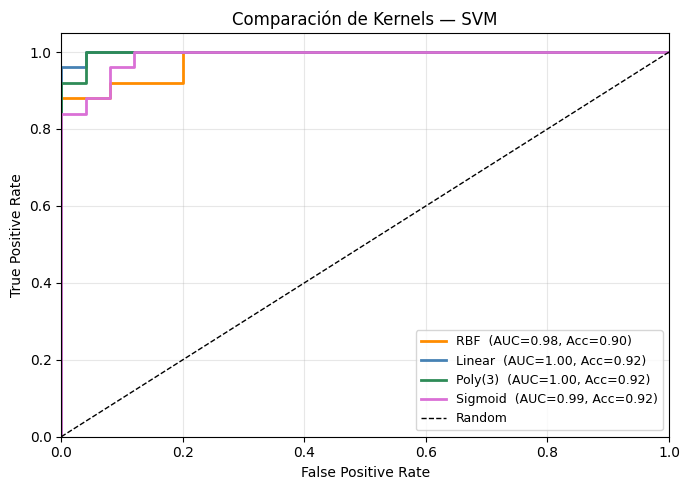

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

iris = datasets.load_iris()
X = iris.data
y = iris.target
X, y = X[y != 0], y[y != 0]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# ── Kernels a comparar ────────────────────────────────────────────────────────
kernels = {
    'RBF':     svm.SVC(kernel='rbf',     C=1.0, gamma='scale', probability=True),
    'Linear':  svm.SVC(kernel='linear',  C=1.0,                probability=True),
    'Poly(3)': svm.SVC(kernel='poly',    C=1.0, gamma='scale',
                       degree=3, coef0=1, probability=True),
    'Sigmoid': svm.SVC(kernel='sigmoid', C=1.0, gamma='scale',
                       coef0=0,          probability=True),
}

colors = ['darkorange', 'steelblue', 'seagreen', 'orchid']

# ── Figura ────────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))

for (name, clf), color in zip(kernels.items(), colors):
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)

    y_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=2)
    roc_auc = auc(fpr, tpr)

    print(f"{name:<10}  Acc={acc:.4f}  AUC={roc_auc:.4f}")
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name}  (AUC={roc_auc:.2f}, Acc={acc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación de Kernels — SVM')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()